In [13]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.gridspec import GridSpec

from fiat_toolbox.well_being import CommunityUnit, WellBeingConfig, CapitalStock, IncomeConfig, SimulationConfig, Liquidity

In [14]:
housing_stock = CapitalStock(v=0.7, k=20000)
labor_stock = CapitalStock(v=0.4, k=5000000, recovery_time=5)
rental_stock = CapitalStock(v=0.7, k=80000, recovery_time=10)
income_config = IncomeConfig(i_0=48000, i_avg=48000, pi=0.15, c_i_ratio=1.0, c_L=3e-2, i_div=10000)
sim_config = SimulationConfig(eta=1.5, rho=0.06, t_max=10, dt=1/52, currency="$", c_min=0.0, recovery_per=95.0)
liq = Liquidity(savings=10000)

config = WellBeingConfig(
    housing=housing_stock,
    labour_assets=labor_stock,
    rental_housing=rental_stock,
    income=income_config,
    simulation=sim_config,
    liquidity=liq
    
)

In [15]:
# Create a WellBeing object and optimize the lambda value
household = CommunityUnit(config=config)
household

CommunityUnit(
  housing = k=20000.0 v=0.7 recovery_time=None recovery_rate=None,
  rental_housing = k=80000.0 v=0.7 recovery_time=10.0 recovery_rate=0.299573227355399,
  labour_assets = k=5000000.0 v=0.4 recovery_time=5.0 recovery_rate=0.599146454710798,
  income = i_0=48000.0 i_avg=48000.0 pi=0.15 c_L=0.03 c_i_ratio=1.0 i_div=10000.0,
  liquidity = savings=10000.0 insurance=0.0 support=0.0,
  simulation = eta=1.5 rho=0.06 t_max=10.0 dt=0.019230769230769232 currency='$' c_min=0.0 recovery_per=95.0
)

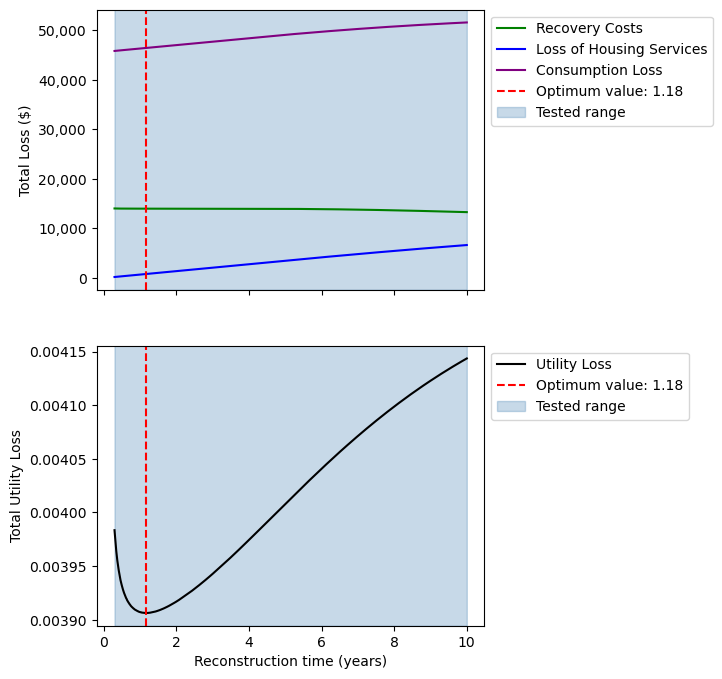

In [16]:
household.opt_lambda(method="trapezoid", eps_rel=0.)
household.plot_opt_lambda(x_type="time");

In [17]:
household.get_losses("trapezoid")

Recovery Costs                       14002.780733
Loss of Housing Services               825.758208
Loss of Housing Services (Rental)    26637.967808
Labour Income Loss                   14983.980741
Consumption Loss                     46446.992043
Utility Loss                             0.003906
Wellbeing Loss                       36607.740364
Asset Loss                           14000.000000
Equity Weighted Loss                 10540.176937
dtype: float64

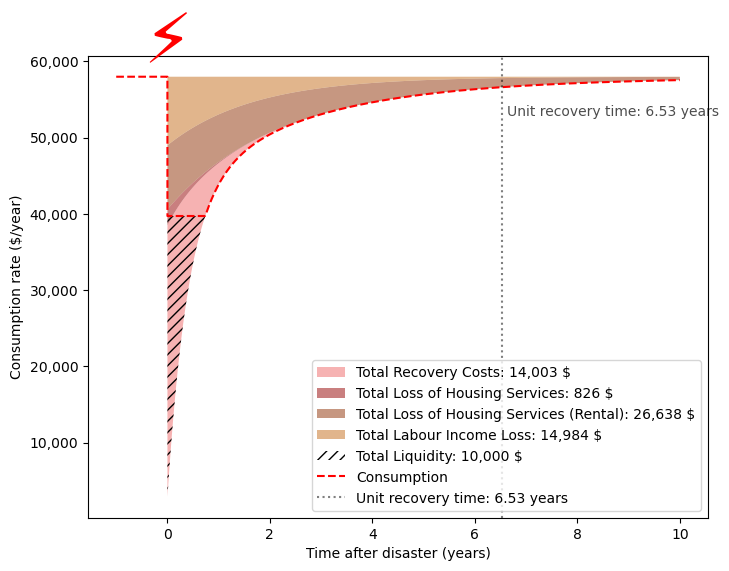

In [18]:
household.plot_consumption()